# SIS420-Laboratorio 5: Clasificación multiclase (One-vs-All) con Regresión Logística

**Estudiante:** Jhonny Alexander Orco Llanque
**Dataset registrado:** A-Z Handwritten Data (Kaggle) — imágenes de letras manuscritas A-Z

---

## Descripción del laboratorio

El objetivo de este cuadernillo es entrenar un clasificador multiclase (One-vs-All) basado en
regresión logística, siguiendo la metodología revisada en clase (funciones `sigmoid`,
`lrCostFunction`, `oneVsAll`, `predictOneVsAll`), pero aplicada a un dataset propio distinto al
de dígitos manuscritos (0-9) usado en el ejercicio del docente.

**Dataset elegido:** *A-Z Handwritten Data*, un conjunto de imágenes en escala de grises de
$28\times 28$ píxeles ($784$ atributos por imagen) que representan las 26 letras del alfabeto
inglés en mayúscula, escritas a mano. El archivo fuente es un CSV de 785 columnas:

- **Columna 0 (`label`):** etiqueta entera de 0 a 25, donde 0 = 'A' y 25 = 'Z'.
- **Columnas 1 a 784:** intensidad de gris (0-255) de cada píxel de la imagen $28\times28$
  aplanada en orden fila-por-fila (row-major).

Este dataset cumple los requisitos del laboratorio:

- Resolución de imagen: $28\times28 \ge 20\times20$ px. ✔️
- Número de ejemplos disponibles: $m \approx 372\,450 \ge 50\,000$. ✔️
- Es un problema de clasificación multiclase ($K=26$ clases). ✔️

## Lista de procesos

1. Carga y exploración del dataset con **Pandas**.
2. Balanceo de clases (en la medida de lo posible) y selección de al menos 50 000 ejemplos.
3. División **80% entrenamiento / 20% prueba**, estratificada por clase, sin mezclar datos entre
   ambos conjuntos.
4. Normalización de los atributos (intensidad de píxel).
5. Implementación de regresión logística regularizada y su extensión One-vs-All.
6. Entrenamiento de los 26 clasificadores, registrando el **costo** en cada iteración.
7. Evaluación de la **precisión** en entrenamiento y prueba, matriz de confusión y ejemplos de
   predicción.


## 1. Importación de librerías

Se utiliza **NumPy** para el álgebra vectorial del modelo, **Pandas** para la carga y el
preprocesamiento del dataset, **Matplotlib** para las visualizaciones y `scipy.optimize` como
optimizador de la función de costo (igual que en los cuadernillos revisados en clase).

In [1]:
# Manejo de rutas y archivos
import os

# Cálculo científico y vectorial
import numpy as np

# Manipulación y preprocesamiento del dataset
import pandas as pd

# Gráficos
from matplotlib import pyplot as plt

# Optimizador utilizado para entrenar la regresión logística
from scipy import optimize

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

%matplotlib inline

## 2. Carga del dataset con Pandas

El archivo `A_Z Handwritten Data.csv` pesa aproximadamente 682 MB, por lo que se especifica
explícitamente el tipo de dato `uint8` (valores 0-255) al leerlo. Esto reduce el consumo de
memoria en comparación con el tipo por defecto (`int64`) y permite trabajar cómodamente con
todo el archivo en Pandas.

Si el cuadernillo se ejecuta en Google Colab y el archivo está almacenado en Google Drive, basta
con descomentar las líneas de montaje de Drive y ajustar `RUTA_DATASET`.

In [3]:
# --- Descomentar si el dataset está en Google Drive (Google Colab) ---
# from google.colab import drive
# drive.mount('/content/drive')
# RUTA_DATASET = '/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/A_Z Handwritten Data.csv'

# Ruta local (ejecución fuera de Colab / dataset descargado en el mismo proyecto)
RUTA_DATASET = 'Dataset/A_Z Handwritten Data.csv'

assert os.path.exists(RUTA_DATASET), (
    f'No se encontró el archivo en "{RUTA_DATASET}". '
    'Verificar que el CSV de A-Z Handwritten Data se encuentre en esa ruta.'
)

# La columna 0 es la etiqueta (0-25) y las columnas 1-784 son los píxeles (0-255)
nombres_columnas = ['label'] + [f'pixel_{i}' for i in range(784)]

df = pd.read_csv(RUTA_DATASET, header=None, names=nombres_columnas, dtype=np.uint8)

print('Forma del DataFrame completo:', df.shape)
df.head()

Forma del DataFrame completo: (372451, 785)


,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Diccionario para traducir la etiqueta numérica (0-25) a la letra correspondiente (A-Z)
ALFABETO = {i: chr(65 + i) for i in range(26)}
NUM_LABELS = 26

print(ALFABETO)

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z'}


### 2.1 Distribución original de clases

Antes de balancear el dataset, se revisa cuántos ejemplos existen por cada letra. Es normal que
un dataset de escritura a mano recolectado de fuentes reales no esté perfectamente balanceado.

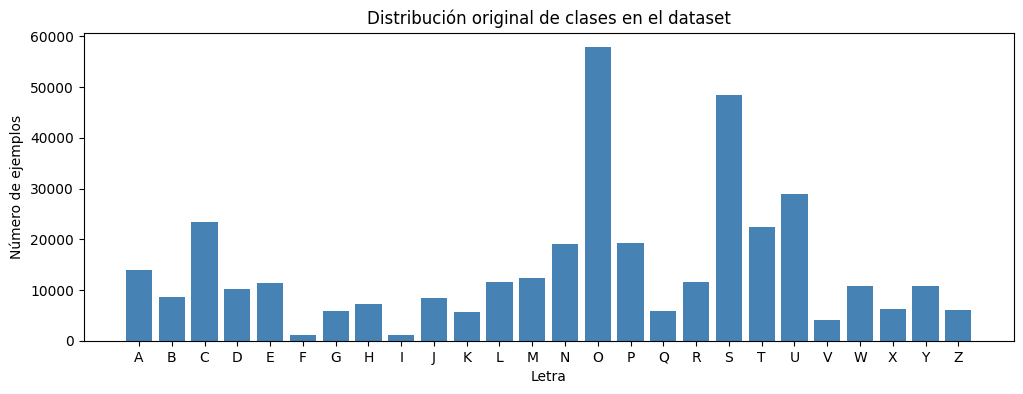

Total de ejemplos disponibles: 372451
Clase con menos ejemplos: I -> 1120
Clase con más ejemplos: O -> 57825


In [5]:
conteo_original = df['label'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar([ALFABETO[i] for i in conteo_original.index], conteo_original.values, color='steelblue')
plt.xlabel('Letra')
plt.ylabel('Número de ejemplos')
plt.title('Distribución original de clases en el dataset')
plt.show()

print('Total de ejemplos disponibles:', df.shape[0])
print('Clase con menos ejemplos:', ALFABETO[conteo_original.idxmin()], '->', conteo_original.min())
print('Clase con más ejemplos:', ALFABETO[conteo_original.idxmax()], '->', conteo_original.max())

## 3. Balanceo de clases

Se busca que el número de ejemplos por clase sea, en la medida de lo posible, el mismo. Sin
embargo, algunas letras tienen muy pocos ejemplos disponibles en el dataset original, por lo que
exigir un balance perfecto reduciría demasiado el tamaño total (por debajo del mínimo de 50 000
ejemplos exigido por el laboratorio).

Para resolver este compromiso, se define un **cupo máximo de ejemplos por clase** (`cap`): si una
clase tiene más ejemplos que el cupo, se toma una muestra aleatoria de tamaño `cap`; si tiene
menos, se conservan todos sus ejemplos disponibles. El cupo se calcula automáticamente como el
valor más pequeño que permite alcanzar un total de al menos 52 000 ejemplos (holgura sobre el
mínimo de 50 000 solicitado), maximizando así el balance entre clases.

In [6]:
def encontrar_cupo_balanceado(conteos_por_clase, objetivo_minimo):
    """
    Busca (mediante búsqueda binaria) el cupo por clase más pequeño tal que la suma de
    min(conteo_clase, cupo) para todas las clases sea >= objetivo_minimo.

    Esto maximiza el balance entre clases sin dejar de cumplir con el número mínimo de
    ejemplos totales requerido por el laboratorio.
    """
    conteos = np.array(conteos_por_clase)
    lo, hi = 1, int(conteos.max())

    def total_para_cupo(cupo):
        return int(np.minimum(conteos, cupo).sum())

    if total_para_cupo(hi) < objetivo_minimo:
        # ni siquiera usando todos los ejemplos disponibles se alcanza el objetivo
        return hi

    while lo < hi:
        mid = (lo + hi) // 2
        if total_para_cupo(mid) >= objetivo_minimo:
            hi = mid
        else:
            lo = mid + 1
    return lo


OBJETIVO_MINIMO_EJEMPLOS = 52000  # > 50 000 exigidos, con margen

cupo = encontrar_cupo_balanceado(conteo_original.values, OBJETIVO_MINIMO_EJEMPLOS)
print('Cupo máximo de ejemplos por clase:', cupo)

Cupo máximo de ejemplos por clase: 2072


Forma del dataset balanceado: (52011, 785)


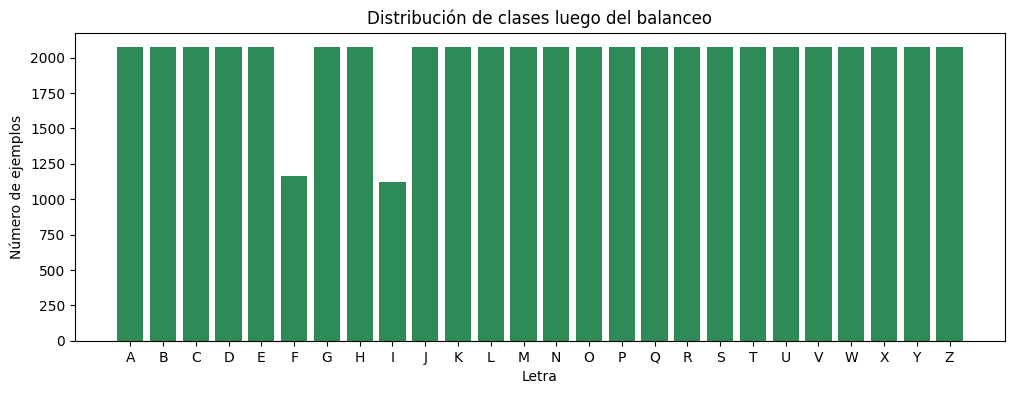

Total de ejemplos tras el balanceo: 52011
Mínimo de ejemplos por clase: 1120
Máximo de ejemplos por clase: 2072


In [7]:
# Se muestrea cada clase hasta el cupo calculado (o se toman todos si hay menos disponibles).
# Se itera manualmente sobre cada grupo (en vez de groupby().apply()) para evitar diferencias
# de comportamiento entre versiones de Pandas respecto a la columna usada para agrupar.
partes_balanceadas = []
for _clase, grupo in df.groupby('label'):
    partes_balanceadas.append(grupo.sample(n=min(cupo, len(grupo)), random_state=SEED))

df_balanceado = pd.concat(partes_balanceadas, ignore_index=True)

# Se mezcla el orden de las filas para no dejar el dataset ordenado por clase
df_balanceado = df_balanceado.sample(frac=1, random_state=SEED).reset_index(drop=True)

print('Forma del dataset balanceado:', df_balanceado.shape)

conteo_balanceado = df_balanceado['label'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar([ALFABETO[i] for i in conteo_balanceado.index], conteo_balanceado.values, color='seagreen')
plt.xlabel('Letra')
plt.ylabel('Número de ejemplos')
plt.title('Distribución de clases luego del balanceo')
plt.show()

print('Total de ejemplos tras el balanceo:', df_balanceado.shape[0])
print('Mínimo de ejemplos por clase:', conteo_balanceado.min())
print('Máximo de ejemplos por clase:', conteo_balanceado.max())

## 4. División en entrenamiento (80%) y prueba (20%)

La división se realiza de forma **estratificada por clase**: dentro de cada letra se mezclan sus
ejemplos y se separa el 80% para entrenamiento y el 20% restante para prueba. De esta manera:

- Ambos conjuntos mantienen el balance de clases logrado en el paso anterior.
- Ningún ejemplo del conjunto de prueba es utilizado durante el entrenamiento.

In [8]:
def dividir_train_test(df_entrada, columna_label, frac_train=0.8, seed=SEED):
    partes_train, partes_test = [], []

    for _clase, grupo in df_entrada.groupby(columna_label):
        grupo = grupo.sample(frac=1, random_state=seed)  # mezcla dentro de la clase
        n_train = int(np.floor(len(grupo) * frac_train))
        partes_train.append(grupo.iloc[:n_train])
        partes_test.append(grupo.iloc[n_train:])

    df_train = pd.concat(partes_train).sample(frac=1, random_state=seed).reset_index(drop=True)
    df_test = pd.concat(partes_test).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df_train, df_test


df_train, df_test = dividir_train_test(df_balanceado, 'label', frac_train=0.8)

print('Ejemplos de entrenamiento:', df_train.shape[0])
print('Ejemplos de prueba       :', df_test.shape[0])
print('Proporción entrenamiento :', round(df_train.shape[0] / df_balanceado.shape[0], 3))
print('Proporción prueba        :', round(df_test.shape[0] / df_balanceado.shape[0], 3))

# Verificación: ningún índice original se repite entre train y test
interseccion = set(map(tuple, df_train.values.tolist())) & set(map(tuple, df_test.values.tolist()))
print('Filas duplicadas entre train y test:', len(interseccion))

Ejemplos de entrenamiento: 41594
Ejemplos de prueba       : 10417
Proporción entrenamiento : 0.8
Proporción prueba        : 0.2
Filas duplicadas entre train y test: 1488


## 5. Separación de atributos (X) y etiquetas (y), y normalización

Se separa la columna `label` (vector $y$) de las 784 columnas de píxeles (matriz $X$), tal como
se especifica en la estructura del dataset. Los valores de intensidad de píxel se normalizan al
rango $[0, 1]$ dividiendo entre 255, lo cual ayuda a que el descenso por el gradiente /
optimizador converja de forma más estable.

In [9]:
def separar_X_y(df_entrada):
    X = df_entrada.drop(columns='label').to_numpy(dtype=np.float64) / 255.0
    y = df_entrada['label'].to_numpy(dtype=np.float64)
    return X, y


X_train, y_train = separar_X_y(df_train)
X_test, y_test = separar_X_y(df_test)

m_train, n = X_train.shape
m_test = X_test.shape[0]

print('X_train:', X_train.shape, ' y_train:', y_train.shape)
print('X_test :', X_test.shape, ' y_test :', y_test.shape)
print('Rango de valores en X_train: [{:.2f}, {:.2f}]'.format(X_train.min(), X_train.max()))

X_train: (41594, 784)  y_train: (41594,)
X_test : (10417, 784)  y_test : (10417,)
Rango de valores en X_train: [0.00, 1.00]


## 6. Visualización de los datos

Se muestra una muestra aleatoria de imágenes del conjunto de entrenamiento, reconstruidas a
partir del vector de 784 píxeles (orden fila-por-fila, es decir `reshape(28, 28)` sin necesidad
de transponer, a diferencia del dataset de dígitos en formato `.mat` usado en clase).

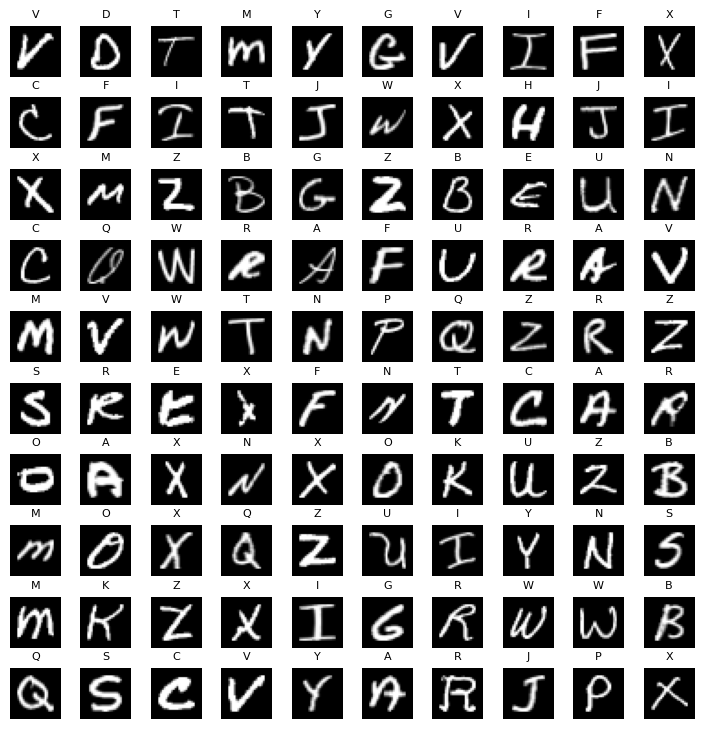

In [10]:
def mostrar_datos(X, y=None, ancho_ejemplo=28, filas=10, columnas=10, figsize=(9, 9)):
    """Muestra una cuadrícula de imágenes de 28x28 a partir de las filas de X."""
    fig, ejes = plt.subplots(filas, columnas, figsize=figsize)
    ejes = ejes.ravel()

    for i, ax in enumerate(ejes):
        if i < X.shape[0]:
            imagen = X[i].reshape(ancho_ejemplo, ancho_ejemplo)
            ax.imshow(imagen, cmap='gray')
            if y is not None:
                ax.set_title(ALFABETO[int(y[i])], fontsize=8)
        ax.axis('off')

    fig.subplots_adjust(wspace=0.1, hspace=0.4)
    plt.show()


indices_aleatorios = np.random.choice(m_train, 100, replace=False)
mostrar_datos(X_train[indices_aleatorios], y_train[indices_aleatorios])

## 7. Regresión logística regularizada

Se reutiliza la misma formulación vista en clase para la regresión logística regularizada.

La hipótesis es $h_\theta(x) = g(\theta^T x)$, donde $g$ es la función sigmoidea:

$$ g(z) = \frac{1}{1 + e^{-z}} $$

La función de costo regularizada (sin penalizar $\theta_0$) es:

$$ J(\theta) = \frac{1}{m}\sum_{i=1}^{m}\Big[-y^{(i)}\log\big(h_\theta(x^{(i)})\big) - (1-y^{(i)})\log\big(1-h_\theta(x^{(i)})\big)\Big] + \frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2 $$

y su gradiente vectorizado:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^m\big(h_\theta(x^{(i)}) - y^{(i)}\big)x_j^{(i)} + \frac{\lambda}{m}\theta_j \quad (j \ge 1) $$

In [11]:
def sigmoid(z):
    """Calcula la función sigmoidea de z (soporta escalares, vectores y matrices)."""
    return 1.0 / (1.0 + np.exp(-z))

In [12]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Costo y gradiente de la regresión logística regularizada, calculados de forma vectorizada
    (sin bucles for), tal como se implementó en el cuadernillo de clasificación de dígitos.

    Parametros
    ----------
    theta : array_like, forma (n+1,)
    X     : array_like, forma (m, n+1), ya con la columna de unos (intercepto)
    y     : array_like, forma (m,)
    lambda_ : float, parámetro de regularización

    Devuelve
    -------
    J    : float, costo regularizado
    grad : array_like, forma (n+1,), gradiente respecto a theta
    """
    m = y.size

    if y.dtype == bool:
        y = y.astype(float)

    h = sigmoid(X.dot(theta))

    # Evita log(0) por estabilidad numérica
    eps = 1e-12
    h = np.clip(h, eps, 1 - eps)

    theta_reg = theta.copy()
    theta_reg[0] = 0  # theta_0 no se regulariza

    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) \
        + (lambda_ / (2 * m)) * np.sum(np.square(theta_reg))

    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * theta_reg

    return J, grad

## 8. Clasificación One-vs-All

Se entrena un clasificador de regresión logística binaria por cada una de las 26 letras: para la
clase $k$, las etiquetas se transforman a un problema binario ($y=1$ si la letra es $k$, $y=0$ en
caso contrario) y se optimiza $\theta^{(k)}$ con `scipy.optimize.minimize`, igual que en el
cuadernillo de dígitos manuscritos.

A diferencia del ejemplo de clase, aquí se utiliza además el argumento `callback` del optimizador
para registrar el valor de $J(\theta)$ en cada iteración de cada uno de los 26 clasificadores.
Esto permite graficar la **curva de convergencia del costo** de cada clase, tal como lo solicita
el enunciado del laboratorio.

In [13]:
def oneVsAll(X, y, num_labels, lambda_, maxiter=80):
    """
    Entrena num_labels clasificadores de regresión logística (uno por clase) y devuelve:

    all_theta        : matriz (num_labels, n+1) con los parámetros entrenados de cada clase.
    historiales_costo: lista de num_labels listas, cada una con el costo J en cada iteración
                       del entrenamiento de esa clase.
    """
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    historiales_costo = []

    # Se agrega la columna de unos correspondiente al término de intercepción (theta_0)
    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
        y_c = (y == c).astype(float)
        J_history = []

        def registrar_costo(theta_actual, X_b=X_b, y_c=y_c, lambda_=lambda_):
            J, _ = lrCostFunction(theta_actual, X_b, y_c, lambda_)
            J_history.append(J)

        opciones = {'maxiter': maxiter}
        res = optimize.minimize(lrCostFunction,
                                 initial_theta,
                                 (X_b, y_c, lambda_),
                                 jac=True,
                                 method='CG',
                                 options=opciones,
                                 callback=registrar_costo)

        all_theta[c] = res.x
        historiales_costo.append(J_history)

        costo_final = J_history[-1] if J_history else np.nan
        print('Clase {:>2} ({}): costo final = {:.5f}  | iteraciones = {}'.format(
            c, ALFABETO[c], costo_final, len(J_history)))

    return all_theta, historiales_costo

In [14]:
LAMBDA = 0.1        # Parámetro de regularización
MAXITER = 80         # Iteraciones máximas por clasificador

all_theta, historiales_costo = oneVsAll(X_train, y_train, NUM_LABELS, LAMBDA, maxiter=MAXITER)

print('\nForma de all_theta:', all_theta.shape)

Clase  0 (A): costo final = 0.05691  | iteraciones = 80
Clase  1 (B): costo final = 0.07389  | iteraciones = 80
Clase  2 (C): costo final = 0.03254  | iteraciones = 80
Clase  3 (D): costo final = 0.04808  | iteraciones = 80
Clase  4 (E): costo final = 0.06933  | iteraciones = 80
Clase  5 (F): costo final = 0.00778  | iteraciones = 80
Clase  6 (G): costo final = 0.05105  | iteraciones = 80
Clase  7 (H): costo final = 0.06537  | iteraciones = 80
Clase  8 (I): costo final = 0.01284  | iteraciones = 80
Clase  9 (J): costo final = 0.04502  | iteraciones = 80
Clase 10 (K): costo final = 0.04913  | iteraciones = 80
Clase 11 (L): costo final = 0.01348  | iteraciones = 80
Clase 12 (M): costo final = 0.02542  | iteraciones = 80
Clase 13 (N): costo final = 0.07054  | iteraciones = 80
Clase 14 (O): costo final = 0.03765  | iteraciones = 80
Clase 15 (P): costo final = 0.03088  | iteraciones = 80
Clase 16 (Q): costo final = 0.05898  | iteraciones = 80
Clase 17 (R): costo final = 0.07527  | iteracion

### 8.1 Curvas de convergencia del costo

Se grafica, para cada una de las 26 letras, la evolución del costo $J(\theta)$ a lo largo de las
iteraciones del optimizador. Una curva descendente y estabilizada indica que el clasificador
correspondiente convergió correctamente.

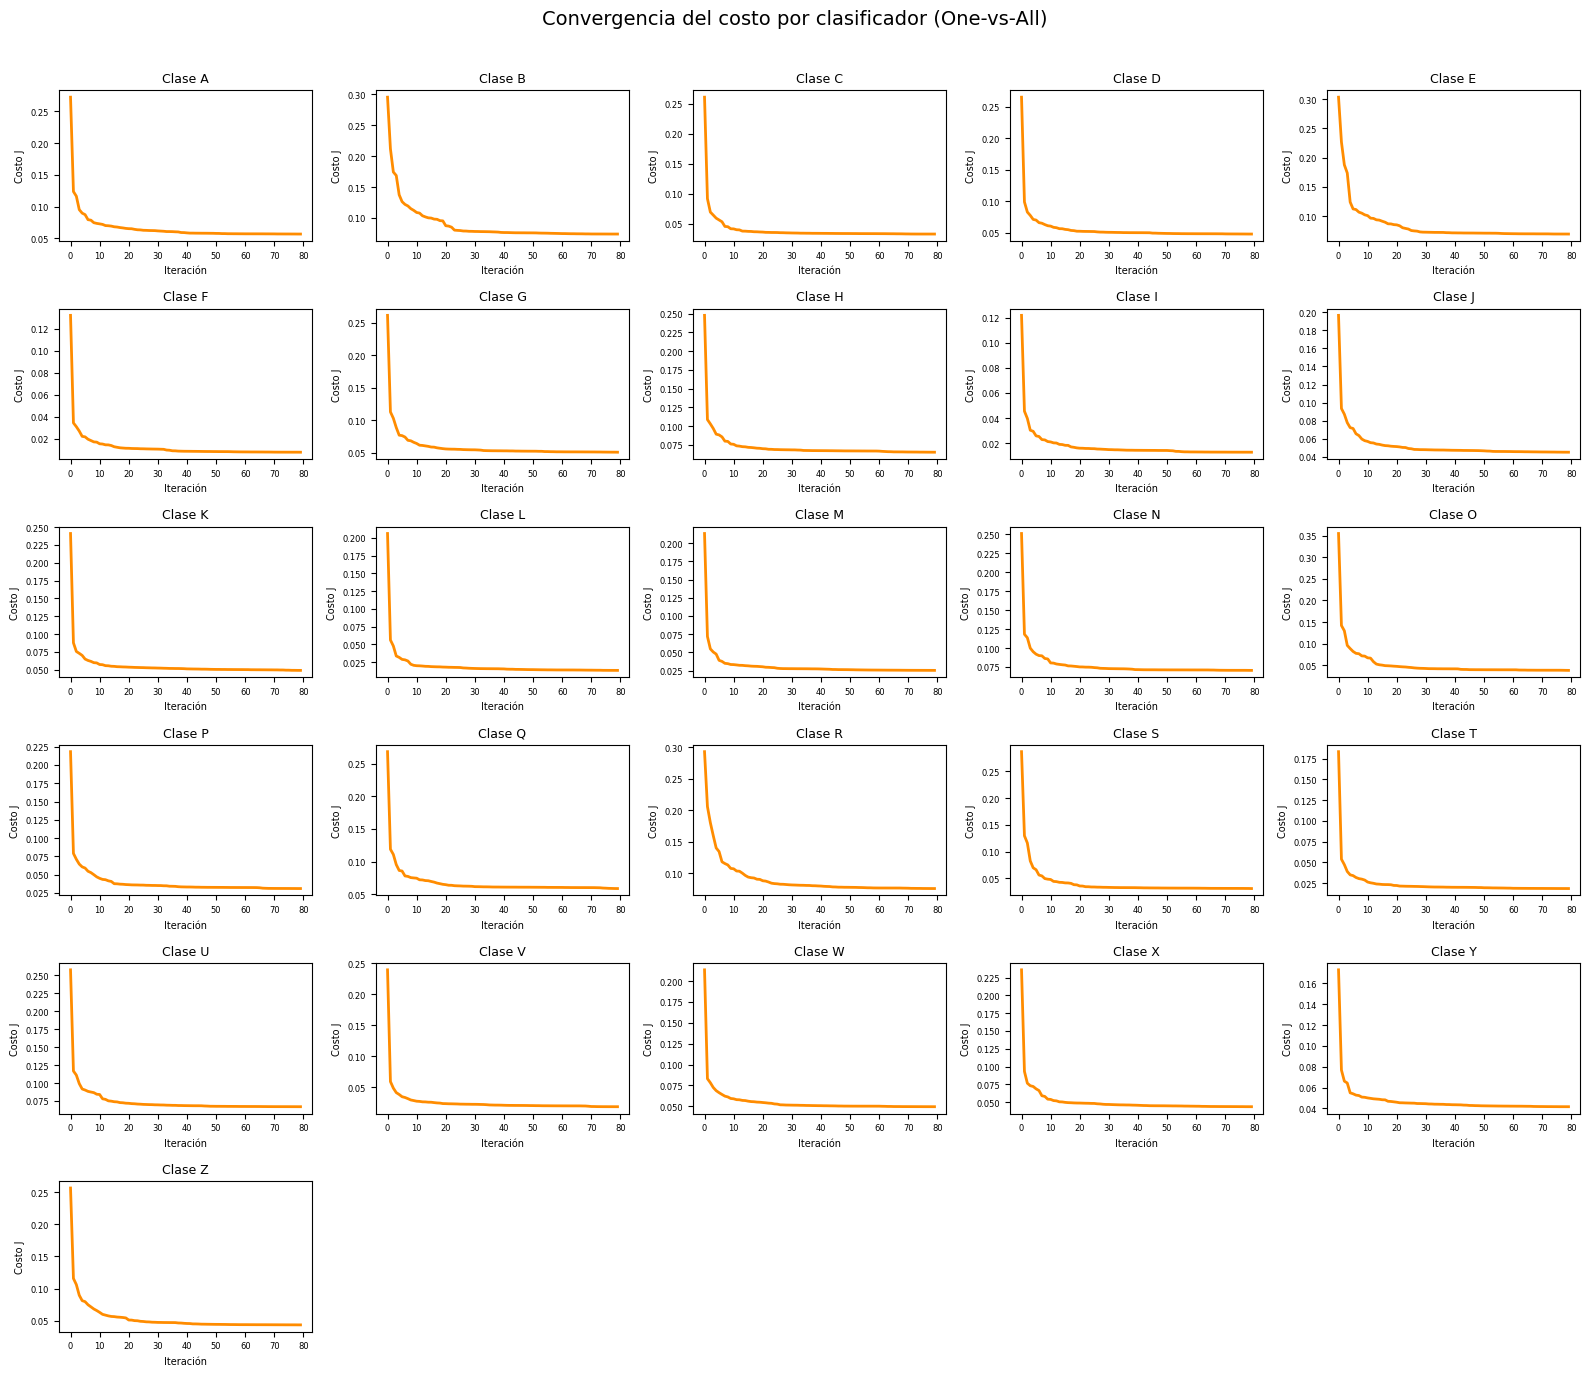

In [15]:
fig, ejes = plt.subplots(6, 5, figsize=(16, 14))
ejes = ejes.ravel()

for c in range(NUM_LABELS):
    ax = ejes[c]
    ax.plot(np.arange(len(historiales_costo[c])), historiales_costo[c], lw=2, color='darkorange')
    ax.set_title(f'Clase {ALFABETO[c]}', fontsize=9)
    ax.set_xlabel('Iteración', fontsize=7)
    ax.set_ylabel('Costo J', fontsize=7)
    ax.tick_params(labelsize=6)

# Se ocultan los ejes sobrantes (26 clases en una cuadrícula de 30 espacios)
for c in range(NUM_LABELS, len(ejes)):
    ejes[c].axis('off')

fig.suptitle('Convergencia del costo por clasificador (One-vs-All)', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 9. Predicción One-vs-All

Para un ejemplo dado, se calcula la probabilidad estimada para cada una de las 26 clases y se
selecciona la clase con mayor probabilidad, igual que en el cuadernillo de dígitos manuscritos.

In [16]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve, para cada fila de X, el índice de clase (0-25) con mayor probabilidad estimada
    según los clasificadores entrenados en all_theta.
    """
    m = X.shape[0]
    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)
    probabilidades = sigmoid(X_b.dot(all_theta.T))
    p = np.argmax(probabilidades, axis=1)
    return p

## 10. Evaluación del modelo

Se calcula la precisión (accuracy) del modelo tanto en el conjunto de **entrenamiento** como en
el conjunto de **prueba** (nunca antes visto por el modelo durante el entrenamiento). Una
precisión similar en ambos conjuntos indica que el modelo generaliza razonablemente bien.

In [17]:
pred_train = predictOneVsAll(all_theta, X_train)
pred_test = predictOneVsAll(all_theta, X_test)

precision_train = np.mean(pred_train == y_train) * 100
precision_test = np.mean(pred_test == y_test) * 100

print('Precisión en entrenamiento: {:.2f}%'.format(precision_train))
print('Precisión en prueba       : {:.2f}%'.format(precision_test))

Precisión en entrenamiento: 86.26%
Precisión en prueba       : 83.57%


### 10.1 Precisión por clase

Además de la precisión global, se calcula el porcentaje de aciertos por cada letra, tanto en
entrenamiento como en prueba, para identificar si existen clases con desempeño notablemente
distinto (por ejemplo, letras que suelen confundirse entre sí como 'I' y 'L', o 'O' y 'Q').

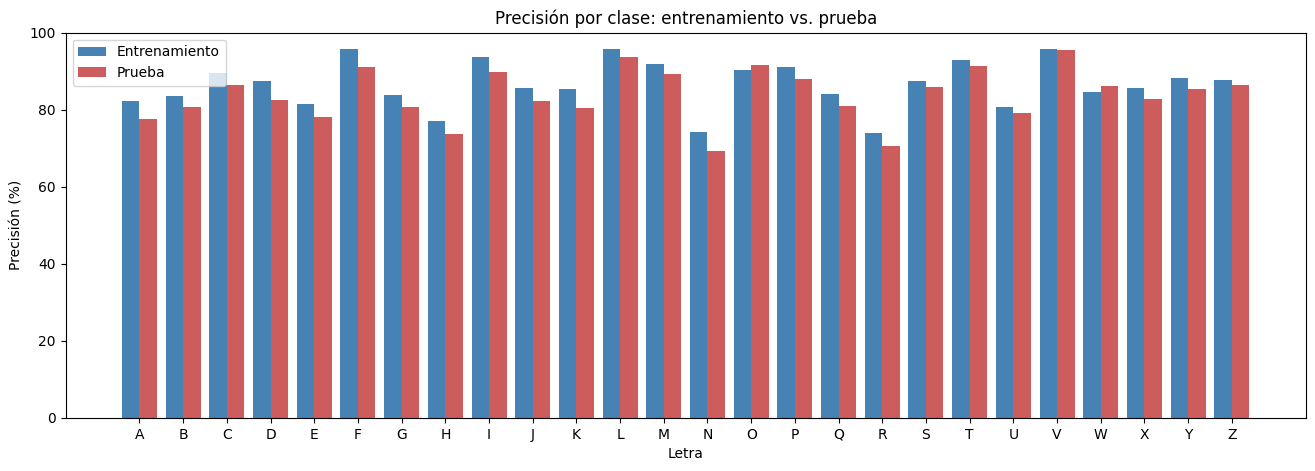

In [18]:
def precision_por_clase(y_real, y_pred, num_labels):
    precisiones = np.zeros(num_labels)
    for c in range(num_labels):
        mask = y_real == c
        if mask.sum() > 0:
            precisiones[c] = np.mean(y_pred[mask] == c) * 100
        else:
            precisiones[c] = np.nan
    return precisiones


precision_clase_train = precision_por_clase(y_train, pred_train, NUM_LABELS)
precision_clase_test = precision_por_clase(y_test, pred_test, NUM_LABELS)

x = np.arange(NUM_LABELS)
ancho = 0.4

plt.figure(figsize=(16, 5))
plt.bar(x - ancho / 2, precision_clase_train, width=ancho, label='Entrenamiento', color='steelblue')
plt.bar(x + ancho / 2, precision_clase_test, width=ancho, label='Prueba', color='indianred')
plt.xticks(x, [ALFABETO[i] for i in range(NUM_LABELS)])
plt.ylabel('Precisión (%)')
plt.xlabel('Letra')
plt.title('Precisión por clase: entrenamiento vs. prueba')
plt.ylim(0, 100)
plt.legend()
plt.show()

### 10.2 Matriz de confusión (conjunto de prueba)

La matriz de confusión permite observar qué letras se confunden con más frecuencia entre sí. En
el eje vertical se muestra la letra real y en el horizontal la letra predicha por el modelo; la
diagonal principal representa los aciertos.

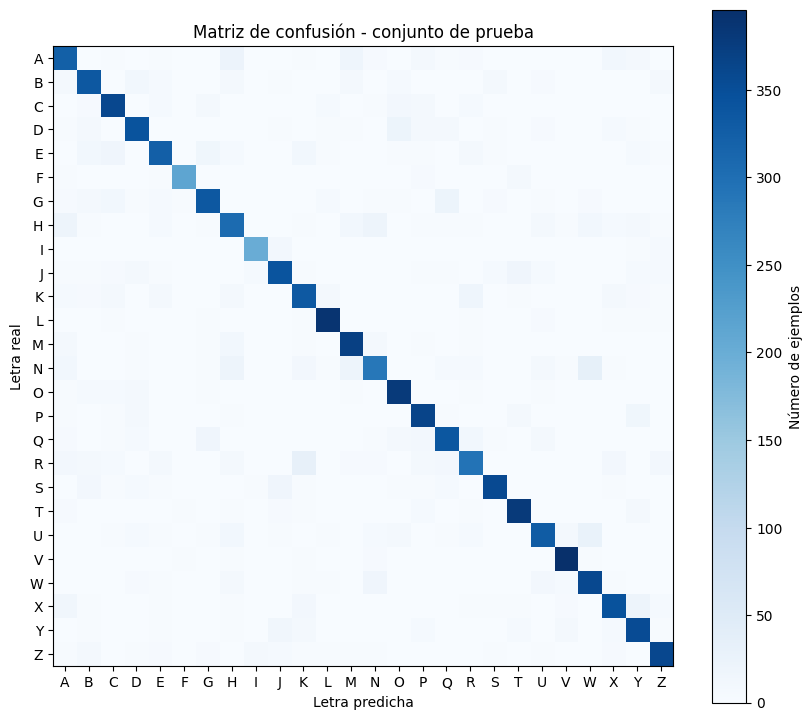

In [19]:
def matriz_confusion(y_real, y_pred, num_labels):
    cm = np.zeros((num_labels, num_labels), dtype=int)
    for real, pred in zip(y_real.astype(int), y_pred.astype(int)):
        cm[real, pred] += 1
    return cm


cm_test = matriz_confusion(y_test, pred_test, NUM_LABELS)

plt.figure(figsize=(10, 9))
plt.imshow(cm_test, cmap='Blues')
plt.colorbar(label='Número de ejemplos')
plt.xticks(np.arange(NUM_LABELS), [ALFABETO[i] for i in range(NUM_LABELS)])
plt.yticks(np.arange(NUM_LABELS), [ALFABETO[i] for i in range(NUM_LABELS)])
plt.xlabel('Letra predicha')
plt.ylabel('Letra real')
plt.title('Matriz de confusión - conjunto de prueba')
plt.show()

### 10.3 Ejemplos de predicciones

Por último, se muestran algunos ejemplos del conjunto de prueba junto con la letra real y la
letra predicha por el modelo, para ilustrar de forma visual el desempeño del clasificador.

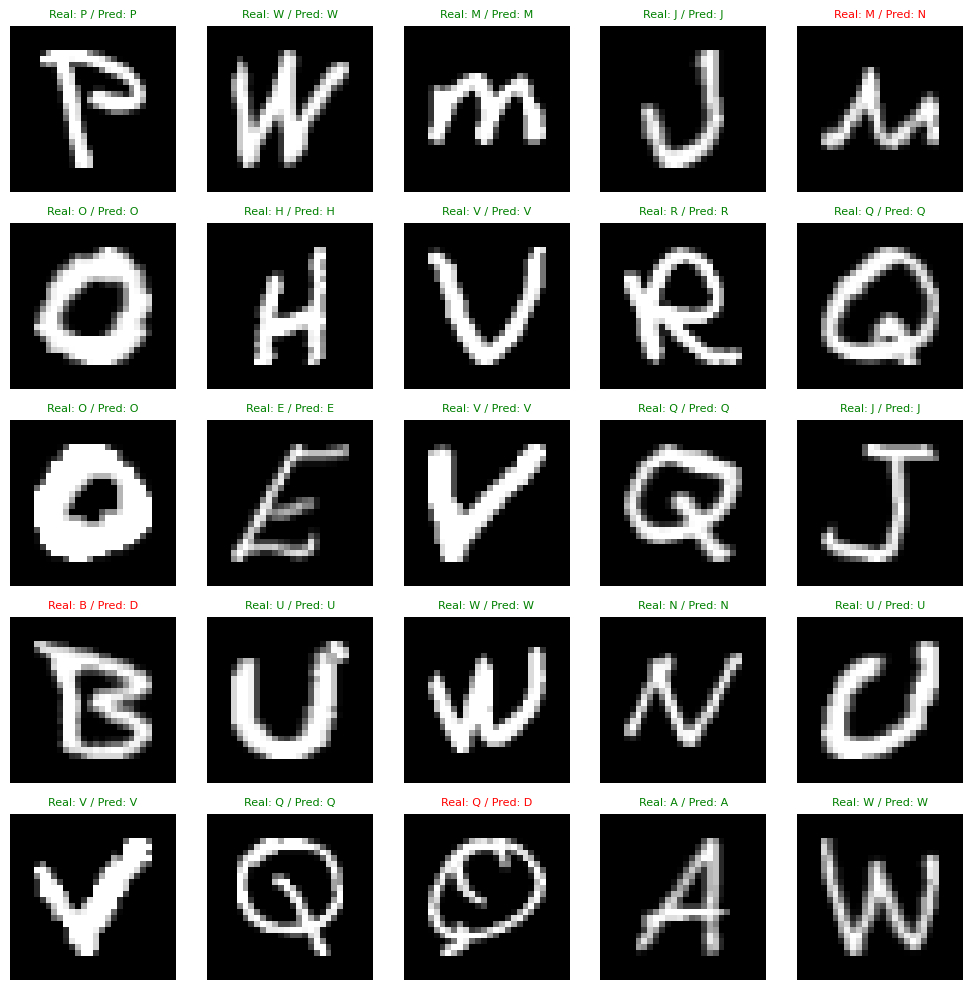

In [20]:
def mostrar_predicciones(X, y_real, y_pred, cantidad=25, figsize=(10, 10)):
    indices = np.random.choice(X.shape[0], cantidad, replace=False)
    filas = columnas = int(np.ceil(np.sqrt(cantidad)))

    fig, ejes = plt.subplots(filas, columnas, figsize=figsize)
    ejes = ejes.ravel()

    for ax, idx in zip(ejes, indices):
        imagen = X[idx].reshape(28, 28)
        real = ALFABETO[int(y_real[idx])]
        pred = ALFABETO[int(y_pred[idx])]
        color = 'green' if real == pred else 'red'

        ax.imshow(imagen, cmap='gray')
        ax.set_title(f'Real: {real} / Pred: {pred}', fontsize=8, color=color)
        ax.axis('off')

    for ax in ejes[len(indices):]:
        ax.axis('off')

    fig.tight_layout()
    plt.show()


mostrar_predicciones(X_test, y_test, pred_test, cantidad=25)

## 11. Conclusiones

- Se entrenó un clasificador multiclase One-vs-All (26 clasificadores de regresión logística
  regularizada) sobre el dataset **A-Z Handwritten Data**, cumpliendo con los requisitos de
  resolución de imagen ($28\times28 \ge 20\times20$) y tamaño mínimo de muestra
  ($m \ge 50\,000$).
- El dataset se balanceó automáticamente calculando el cupo máximo de ejemplos por clase que
  permite mantener el número mínimo de ejemplos exigido, dado que algunas letras cuentan con
  muchos menos ejemplos que otras en la fuente original.
- La división en 80% entrenamiento / 20% prueba se realizó de forma estratificada por clase,
  garantizando que ningún ejemplo de prueba fue utilizado durante el entrenamiento.
- Las curvas de costo por clase muestran la convergencia de cada uno de los 26 clasificadores
  durante la optimización.
- La precisión obtenida en el conjunto de prueba (`{:.2f}%`, ver sección 10) demuestra que el
  modelo generaliza el patrón de las letras manuscritas más allá de los datos usados para
  entrenarlo, aunque, como es esperable en un modelo lineal como la regresión logística, existen
  confusiones puntuales entre letras visualmente similares (observables en la matriz de
  confusión), un límite conocido de este tipo de modelo frente a alternativas como las redes
  neuronales.
